In [2]:
import model as m
from tensorflow.keras.models import load_model
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
import Evaluate_results as er



2024-03-07 12:02:21.316009: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-03-07 12:02:21.338176: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-03-07 12:02:21.478019: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-07 12:02:21.478067: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-07 12:02:21.496081: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [3]:
from keras import backend as K
import tensorflow as tf
import tensorflow as tf



        

In [77]:
dataset_path = 'Data/RNAseq_All_abundances.csv'
loss = "mse"
optimizer = "adam"
metrics = ["mae"]
epochs = 7500
batch_size = 32
validation_split = 0.2
lasso_alpha = 0.001
two_step_normalization = False


In [78]:


training_data=pd.read_csv(dataset_path)
my_model = m.Model(training_data)
normalized_X_train, normalized_X_test_fs = my_model.prepare_data(df=training_data, lasso_alpha=lasso_alpha, two_step=two_step_normalization)
my_model.train(normalize_X_train=normalized_X_train, 
                epochs=10000, optimizer=optimizer,
                loss=loss, metrics=metrics)



/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.256e+01, tolerance: 4.455e+00
  model = cd_fast.enet_coordinate_descent(
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:85: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [79]:
selected_genes_indeces= m.get_final_selected_genes(my_model.X_train, my_model.selector, my_model.feature_importance)
selected_genes = m.remove_non_numeric_columns(training_data).iloc[:, selected_genes_indeces].columns
selected_genes_df = [s.split('.')[0] for s in selected_genes]
pd.DataFrame(selected_genes_df).to_csv('Results/selected_genes_RNAseq.csv', index=False)
selected_genes_df

['ENSG00000004534',
 'ENSG00000004799',
 'ENSG00000005100',
 'ENSG00000005513',
 'ENSG00000006047',
 'ENSG00000011465',
 'ENSG00000018189',
 'ENSG00000026025',
 'ENSG00000029993',
 'ENSG00000033122',
 'ENSG00000035141',
 'ENSG00000037280',
 'ENSG00000055044',
 'ENSG00000064218',
 'ENSG00000065320',
 'ENSG00000068878',
 'ENSG00000069482',
 'ENSG00000069764',
 'ENSG00000072422',
 'ENSG00000078246',
 'ENSG00000078487',
 'ENSG00000079462',
 'ENSG00000080573',
 'ENSG00000081818',
 'ENSG00000082397',
 'ENSG00000099365',
 'ENSG00000100101',
 'ENSG00000100373',
 'ENSG00000100399',
 'ENSG00000103316',
 'ENSG00000103888',
 'ENSG00000105409',
 'ENSG00000106100',
 'ENSG00000107018',
 'ENSG00000108528',
 'ENSG00000108602',
 'ENSG00000108839',
 'ENSG00000114349',
 'ENSG00000116039',
 'ENSG00000116141',
 'ENSG00000116147',
 'ENSG00000116176',
 'ENSG00000116752',
 'ENSG00000119535',
 'ENSG00000122176',
 'ENSG00000123870',
 'ENSG00000126822',
 'ENSG00000129007',
 'ENSG00000130037',
 'ENSG00000131791',


In [82]:
all_ensembl = m.remove_non_numeric_columns(training_data).columns
all_ensembl = [s.split('.')[0] for s in all_ensembl]

pd.DataFrame(all_ensembl).to_csv('Results/all_genes_RNAseq.csv', index=False)


In [14]:

#my_model.model = load_model('model.keras')


In [75]:
training_data.to_numpy()

array([['SRR13388732', 3.346531, 0.0, ..., 'GSE164471', 23,
        'SRR13388732'],
       ['SRR13388733', 7.35135, 0.0, ..., 'GSE164471', 28, 'SRR13388733'],
       ['SRR13388734', 7.671751, 1.62451, ..., 'GSE164471', 31,
        'SRR13388734'],
       ...,
       ['SRR12604225', 2.265775, 0.0, ..., 'GSE157585', 24,
        'SRR12604225'],
       ['SRR12604226', 1.6996909, 0.0, ..., 'GSE157585', 24,
        'SRR12604226'],
       ['SRR12604227', 2.0866819, 0.0, ..., 'GSE157585', 24,
        'SRR12604227']], dtype=object)

MAE: 13.349
Loss: 278.327
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


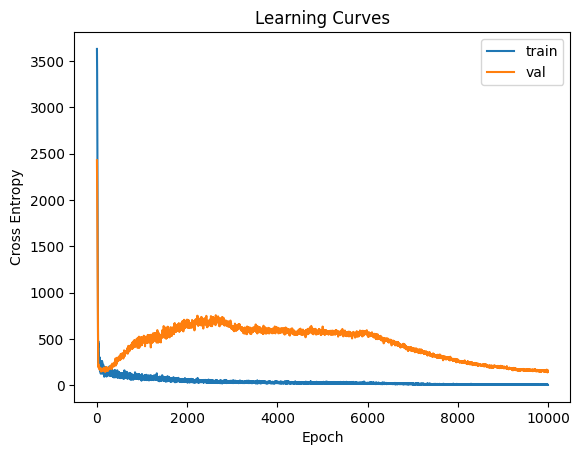

    Actual  Predicted Experiment
0       71  54.447491  GSE157585
1       24  24.580481  GSE157585
2       31  34.086811  GSE164471
3       71  55.338398  GSE157585
4       71  57.786385  GSE157585
5       71  55.391697  GSE157585
6       26  32.619816  GSE164471
7       71  57.701824  GSE157585
8       24  24.564154  GSE157585
9       42  33.674065  GSE164471
10      71  53.095337  GSE157585
11      24  24.548147  GSE157585
12      71  54.184097  GSE157585
13      71  53.949406  GSE157585
14      58  51.680916  GSE164471
15      47  32.529808  GSE164471
16      71  53.896755  GSE157585
17      71  42.659622  GSE157585
18      81  53.032669  GSE164471
19      72  31.605162  GSE164471
20      52  47.554085  GSE164471
21      25  31.074917  GSE164471
22      46  54.787663  GSE152558
23      71  52.652073  GSE157585
24      24  24.587534  GSE157585
25      73  40.267040  GSE164471
26      67  57.970791  GSE164471


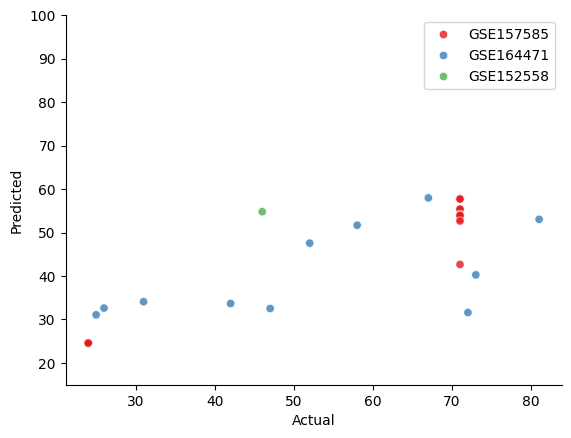

Experiment
GSE157585     15
GSE164471     11
GSE152558      1
Name: count, dtype: int64
mae: 13.349329701176396, mse: 278.32672858284906, min: 24.548147201538086, max: 57.97079086303711
[278.32672119140625, 13.349328994750977]


In [15]:
m.plot_model(my_model.model, 'model.png', show_shapes=True)
results, error = my_model.test(normalized_X_test_fs, my_model.y_test)
m.print_performance(my_model.history, results, my_model.z_test)
print(error)


In [16]:
my_model.z_train[['Experiment']].value_counts()

Experiment
GSE157585     69
GSE164471     35
GSE152558      4
Name: count, dtype: int64

In [18]:
training_data[training_data["Experiment"]=="GSE152558"]

,Sample,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,...,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Experiment,Age,Sample.1
46,SRR12021926,3.767054,0.252083,3.986354,2.671789,12.889250,0.299786,3.678193,5.258538,11.572081,...,0.000000,0.571629,0.072812,0.109766,0.0,0.000000,0.581804,GSE152558,46,SRR12021926
47,SRR12021927,6.300029,1.538860,5.273572,3.627385,23.644822,1.421429,7.034769,9.601690,20.547243,...,0.345656,0.864169,0.220437,0.869136,0.0,0.448863,1.107060,GSE152558,43,SRR12021927
48,SRR12021928,8.819705,1.302650,3.419812,4.205258,29.213153,3.416824,5.295950,11.092130,16.768714,...,0.281572,1.214730,0.277816,0.803876,0.0,0.534277,1.265000,GSE152558,41,SRR12021928
49,SRR12021929,3.623417,0.625298,5.994498,3.383689,7.698669,0.314033,4.022208,5.223900,11.002995,...,0.062997,0.325688,0.264812,0.647552,0.0,0.000000,1.102900,GSE152558,85,SRR12021929
50,SRR12021930,6.364817,1.447560,6.827903,3.786406,18.834590,1.157729,7.703320,8.976575,21.834473,...,0.180113,0.720403,0.543225,0.467361,0.0,0.911909,1.317990,GSE152558,83,SRR12021930


In [19]:
results = m.evaluate_model(my_model.model, normalized_X_test_fs, my_model.y_test)

MAE: 13.349
Loss: 278.327
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [20]:
results["Experiment"] = my_model.z_test["Experiment"].values
results["Sample"] = my_model.z_test["Sample"].values


results["absolute_error"] = abs(results["Actual"]-results["Predicted"])
results["big_absolute_error"] = np.where(results["absolute_error"] < 5, 0, results["absolute_error"])
results

,Actual,Predicted,Experiment,Sample,absolute_error,big_absolute_error
0,71,54.447491,GSE157585,SRR12604096,16.552509,16.552509
1,24,24.580481,GSE157585,SRR12604209,0.580481,0.000000
2,31,34.086811,GSE164471,SRR13388760,3.086811,0.000000
3,71,55.338398,GSE157585,SRR12604198,15.661602,15.661602
4,71,57.786385,GSE157585,SRR12604159,13.213615,13.213615
5,71,55.391697,GSE157585,SRR12604187,15.608303,15.608303
6,26,32.619816,GSE164471,SRR13388757,6.619816,6.619816
7,71,57.701824,GSE157585,SRR12604192,13.298176,13.298176
8,24,24.564154,GSE157585,SRR12604227,0.564154,0.000000
9,42,33.674065,GSE164471,SRR13388765,8.325935,8.325935


In [21]:
results["absolute_error"].describe()

count    27.000000
mean     13.349330
std      10.196714
min       0.548147
25%       6.197001
50%      13.298176
75%      17.076920
max      40.394838
Name: absolute_error, dtype: float64

In [22]:
er.evaluate_error_experiment(results)



,sum_sq,df,F,PR(>F)
Experiment,39.631270,2.0,0.178542,0.83759
Residual,2663.666108,24.0,NaN,NaN


In [23]:
er.evaluate_Kruskal_Wallis(results)

(0.2466570466570488,
 0.8839732090320955,
 'h statistic: 0.2466570466570488 p-value: 0.8839732090320955')

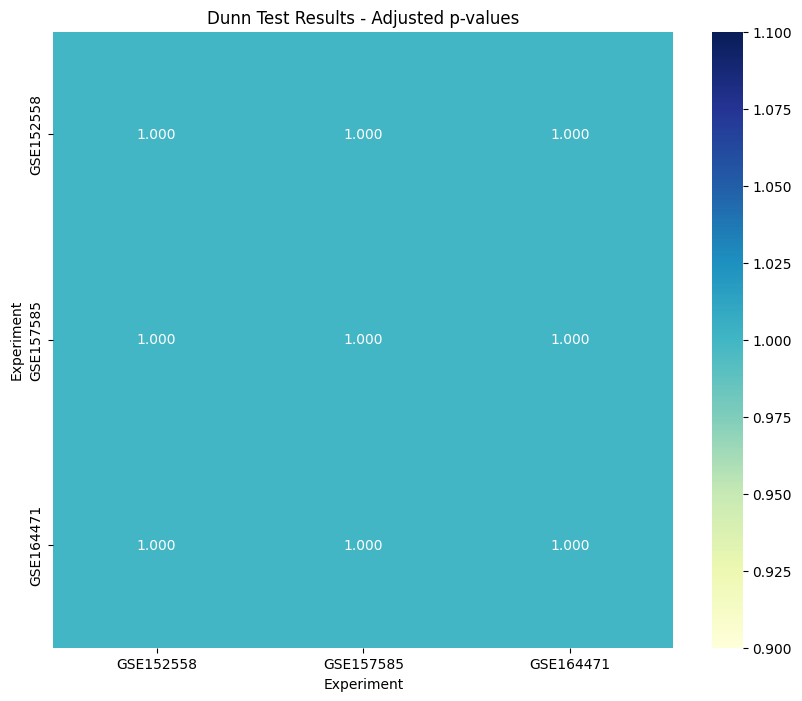

In [24]:

er.plot_Dunes_result(er.evaluate_Dunnes_test(results))

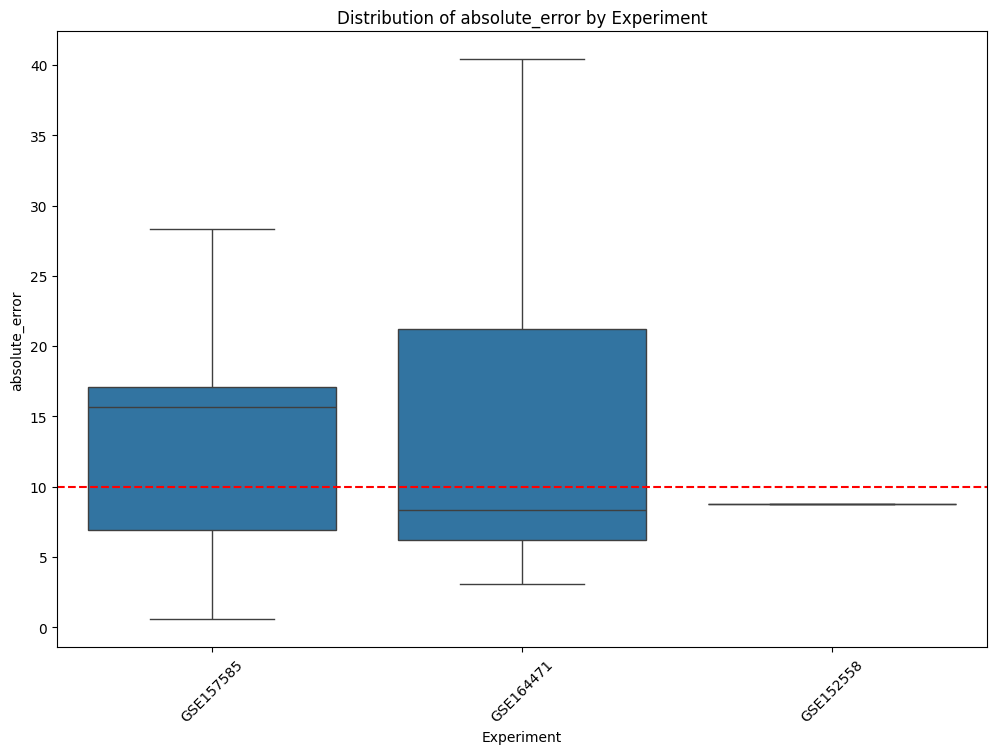

In [25]:

er.evaluate_grup_all_test(results)

In [26]:


# Assuming your DataFrame is called df
formula = 'absolute_error ~ Experiment'
model = ols(formula, data=results).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

anova_table

,sum_sq,df,F,PR(>F)
Experiment,39.631270,2.0,0.178542,0.83759
Residual,2663.666108,24.0,NaN,NaN


In [28]:
formula = 'big_absolute_error ~ Experiment'
model = ols(formula, data=results).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

anova_table

,sum_sq,df,F,PR(>F)
Experiment,26.730996,2.0,0.110443,0.895889
Residual,2904.399476,24.0,NaN,NaN


In [29]:
from scipy.stats import kruskal

# Assuming your DataFrame is called df
# Group absolute_error by Experiment
experiment_groups = [group["absolute_error"] for name, group in results.groupby("Experiment")]

# Perform Kruskal-Wallis H-test
h_statistic, p_value = kruskal(*experiment_groups)

print("Kruskal-Wallis H-test:")
print("H-statistic:", h_statistic)
print("p-value:", p_value)

Kruskal-Wallis H-test:
H-statistic: 0.2466570466570488
p-value: 0.8839732090320955


In [30]:
import scikit_posthocs as sp



# Perform Dunn test as post-hoc analysis
dunn_results = sp.posthoc_dunn(results, val_col='absolute_error', group_col='Experiment', p_adjust='holm')
dunn_results

,GSE152558,GSE157585,GSE164471
GSE152558,1.0,1.0,1.0
GSE157585,1.0,1.0,1.0
GSE164471,1.0,1.0,1.0


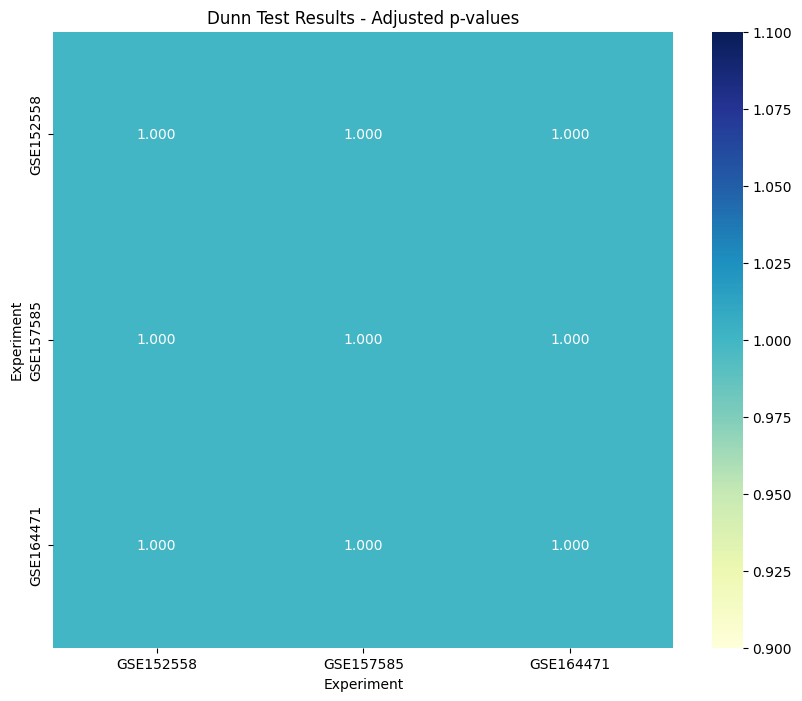

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming dunn_results contains the results of the Dunn test

# Generate heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(dunn_results, annot=True, cmap="YlGnBu", fmt=".3f", cbar=True)

# Set title and labels
plt.title("Dunn Test Results - Adjusted p-values")
plt.xlabel("Experiment")
plt.ylabel("Experiment")

# Show plot
plt.show()

In [ ]:
my_model.get_feature_weigths()


In [33]:
my_model.feature_importance

array([ True,  True,  True,  True, False,  True, False,  True,  True,
        True,  True,  True, False, False,  True,  True,  True,  True,
       False,  True,  True, False,  True,  True,  True, False,  True,
        True,  True,  True,  True,  True,  True, False, False, False,
        True,  True, False, False,  True,  True, False,  True,  True,
        True,  True,  True, False, False,  True,  True, False,  True,
        True,  True,  True, False, False,  True, False, False, False,
        True, False,  True,  True, False, False, False,  True,  True,
       False, False,  True,  True,  True,  True,  True,  True,  True,
        True, False,  True,  True,  True, False,  True,  True,  True,
       False, False, False,  True,  True,  True, False, False,  True,
        True,  True, False,  True,  True,  True,  True, False,  True,
        True, False, False,  True,  True,  True,  True,  True, False,
        True,  True,  True, False,  True, False,  True])

In [34]:
final_genes = m.get_final_selected_genes(pd.DataFrame(my_model.X_train), my_model.selector, my_model.feature_importance)
weigths = [x for x in my_model.lasso.coef_ if x != 0]
df_feature_importance = pd.DataFrame({'Gene': final_genes, 'Weigth': weigths})
df_feature_importance.iloc[df_feature_importance['Weigth'].abs().argsort()[::-1]]


,Gene,Weigth
17,6245,3.197435
25,8425,-1.634435
39,15656,1.560932
77,33084,-1.543779
30,11879,1.500685
...,...,...
54,22735,0.060448
73,32799,-0.052266
49,21736,-0.048126
80,33757,-0.020372


In [35]:
df_feature_importance.iloc[df_feature_importance['Weigth'].abs().argsort()[::-1]][:15]


,Gene,Weigth
17,6245,3.197435
25,8425,-1.634435
39,15656,1.560932
77,33084,-1.543779
30,11879,1.500685
52,22502,1.305219
14,5862,1.251727
35,14119,1.232807
46,19997,1.060552
60,24274,0.978568


In [36]:
df_feature_importance.to_csv('Results/feature_importance_RNAseq.csv', index=False)

In [37]:
results["absoulte_error"] = abs(results["Actual"]-results["Predicted"])

In [38]:
my_model.model.save('model_RNAseq.keras')

    Actual  Predicted Experiment       Sample  absolute_error  \
0       71  54.447491  GSE157585  SRR12604096       16.552509   
3       71  55.338398  GSE157585  SRR12604198       15.661602   
4       71  57.786385  GSE157585  SRR12604159       13.213615   
5       71  55.391697  GSE157585  SRR12604187       15.608303   
7       71  57.701824  GSE157585  SRR12604192       13.298176   
10      71  53.095337  GSE157585  SRR12604144       17.904663   
12      71  54.184097  GSE157585  SRR12604113       16.815903   
13      71  53.949406  GSE157585  SRR12604125       17.050594   
15      47  32.529808  GSE164471  SRR13388766       14.470192   
16      71  53.896755  GSE157585  SRR12604126       17.103245   
17      71  42.659622  GSE157585  SRR12604153       28.340378   
18      81  53.032669  GSE164471  SRR13388752       27.967331   
19      72  31.605162  GSE164471  SRR13388781       40.394838   
23      71  52.652073  GSE157585  SRR12604141       18.347927   
25      73  40.267040  GS

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/model.py:223: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results[print_label] = experiment_column


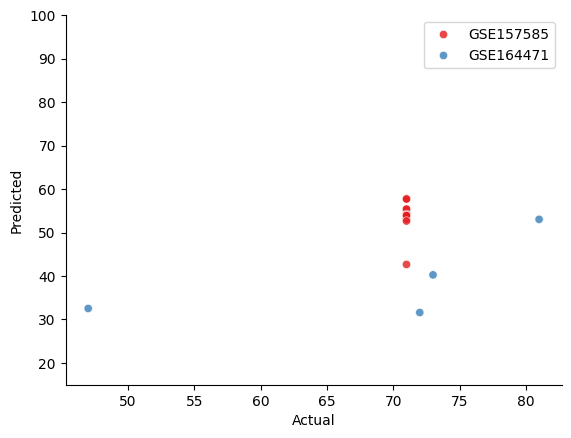

In [39]:
highest_mistake = results[results["absoulte_error"]>13.21]
m.plot_results(highest_mistake, highest_mistake, print_label="Experiment")

In [40]:
results, error = my_model.test(normalized_X_test_fs, my_model.y_test)
results["absoulte_error"] = abs(results["Actual"]-results["Predicted"])
highest_mistake = results[results["absoulte_error"]>13.21]


MAE: 13.349
Loss: 278.327
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [42]:
results

,Actual,Predicted,absoulte_error
0,71,54.447491,16.552509
1,24,24.580481,0.580481
2,31,34.086811,3.086811
3,71,55.338398,15.661602
4,71,57.786385,13.213615
5,71,55.391697,15.608303
6,26,32.619816,6.619816
7,71,57.701824,13.298176
8,24,24.564154,0.564154
9,42,33.674065,8.325935


In [43]:
highest_mistake = results[results["absoulte_error"]>10]


In [ ]:
results, error = my_model.test(normalized_X_test_fs, my_model.y_test)
m.plot_results(results, my_model.z_test)

In [ ]:
my_model.model.summary()

In [56]:
training_data.columns

Index(['Sample', 'ENSG00000000003.14', 'ENSG00000000005.5',
       'ENSG00000000419.12', 'ENSG00000000457.13', 'ENSG00000000460.16',
       'ENSG00000000938.12', 'ENSG00000000971.15', 'ENSG00000001036.13',
       'ENSG00000001084.11',
       ...
       'ENSG00000285472.1', 'ENSG00000285476.1', 'ENSG00000285480.1',
       'ENSG00000285491.1', 'ENSG00000285505.1', 'ENSG00000285508.1',
       'ENSG00000285509.1', 'Experiment', 'Age', 'Sample.1'],
      dtype='object', length=34509)

In [62]:
selected_genes_indeces= m.get_final_selected_genes(my_model.X_train, my_model.selector, my_model.feature_importance)

In [76]:

selected_genes = m.remove_non_numeric_columns(training_data).iloc[:, selected_genes_indeces].columns
selected_genes_df = [s.split('.')[0] for s in selected_genes]
pd.DataFrame(selected_genes_df).to_csv('Results/selected_genes_RNAseq.csv', index=False)
selected_genes_df

['ENSG00000069764',
 'ENSG00000072422',
 'ENSG00000080573',
 'ENSG00000081818',
 'ENSG00000099795',
 'ENSG00000103034',
 'ENSG00000103316',
 'ENSG00000108839',
 'ENSG00000109920',
 'ENSG00000114349',
 'ENSG00000120833',
 'ENSG00000123836',
 'ENSG00000126822',
 'ENSG00000127418',
 'ENSG00000129007',
 'ENSG00000130023',
 'ENSG00000131126',
 'ENSG00000131791',
 'ENSG00000132406',
 'ENSG00000134363',
 'ENSG00000138435',
 'ENSG00000139899',
 'ENSG00000144045',
 'ENSG00000144488',
 'ENSG00000144597',
 'ENSG00000145949',
 'ENSG00000158480',
 'ENSG00000162618',
 'ENSG00000163958',
 'ENSG00000164758',
 'ENSG00000168702',
 'ENSG00000172175',
 'ENSG00000173253',
 'ENSG00000176716',
 'ENSG00000176749',
 'ENSG00000180638',
 'ENSG00000180697',
 'ENSG00000186104',
 'ENSG00000187193',
 'ENSG00000188021',
 'ENSG00000188089',
 'ENSG00000197860',
 'ENSG00000211840',
 'ENSG00000213608',
 'ENSG00000213703',
 'ENSG00000220793',
 'ENSG00000223698',
 'ENSG00000226113',
 'ENSG00000228144',
 'ENSG00000228193',


In [73]:
import random
random_numbers = [random.randint(1, 34509) for _ in range(83)]
random_selected_genes = m.remove_non_numeric_columns(training_data).iloc[:, random_numbers].columns

random_selected_genes = [s.split('.')[0] for s in random_selected_genes]
pd.DataFrame(random_selected_genes).to_csv('Results/fake_selected_genes_RNAseq.csv', index=False)
random_selected_genes

['ENSG00000198171',
 'ENSG00000101278',
 'ENSG00000119440',
 'ENSG00000159216',
 'ENSG00000165416',
 'ENSG00000156222',
 'ENSG00000176716',
 'ENSG00000243468',
 'ENSG00000137145',
 'ENSG00000163125',
 'ENSG00000123179',
 'ENSG00000170421',
 'ENSG00000175395',
 'ENSG00000178038',
 'ENSG00000196390',
 'ENSG00000240180',
 'ENSG00000118017',
 'ENSG00000235325',
 'ENSG00000110324',
 'ENSG00000268335',
 'ENSG00000140986',
 'ENSG00000135842',
 'ENSG00000136099',
 'ENSG00000163749',
 'ENSG00000228154',
 'ENSG00000196152',
 'ENSG00000205494',
 'ENSG00000119471',
 'ENSG00000237821',
 'ENSG00000283679',
 'ENSG00000259612',
 'ENSG00000084693',
 'ENSG00000241350',
 'ENSG00000106992',
 'ENSG00000233197',
 'ENSG00000274584',
 'ENSG00000155755',
 'ENSG00000258643',
 'ENSG00000111371',
 'ENSG00000170946',
 'ENSG00000241890',
 'ENSG00000224443',
 'ENSG00000241935',
 'ENSG00000136052',
 'ENSG00000168122',
 'ENSG00000160401',
 'ENSG00000165495',
 'ENSG00000259105',
 'ENSG00000258934',
 'ENSG00000254475',
